In [1]:
from google.colab import userdata
import os
from huggingface_hub import login
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
login(userdata.get("HF_API_KEY"))

In [2]:
!kaggle competitions download -c super-ai-engineer-ss-6-thai-language-image-captioning

100% 1.75G/1.75G [00:17<00:00, 105MB/s] 



In [3]:
!unzip "/content/super-ai-engineer-ss-6-thai-language-image-captioning.zip"
!rm "/content/super-ai-engineer-ss-6-thai-language-image-captioning.zip"

Streaming output truncated to the last 5000 lines.
  inflating: train/train/travel/15347.jpg  
  inflating: train/train/travel/15348.jpg  
  inflating: train/train/travel/15349.jpg  
  inflating: train/train/travel/15350.jpg  
  inflating: train/train/travel/15351.jpg  
  inflating: train/train/travel/15352.jpg  
  inflating: train/train/travel/15353.jpg  
  inflating: train/train/travel/15354.jpg  
  inflating: train/train/travel/15355.jpg  
  inflating: train/train/travel/15356.jpg  
  inflating: train/train/travel/15357.jpg  
  inflating: train/train/travel/15358.jpg  
  inflating: train/train/travel/15359.jpg  
  inflating: train/train/travel/15360.jpg  
  inflating: train/train/travel/15361.jpg  
  inflating: train/train/travel/15362.jpg  
  inflating: train/train/travel/15363.jpg  
  inflating: train/train/travel/15364.jpg  
  inflating: train/train/travel/15365.jpg  
  inflating: train/train/travel/15366.jpg  
  inflating: train/train/travel/15367.jpg  
  inflating: train/train/

In [4]:
!pip install unsloth peft accelerate bitsandbytes trl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 162.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22

In [5]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
    # fast_inference = False
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

In [7]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 8,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 8,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

In [8]:
print(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3VLForConditionalGeneration(
      (model): Qwen3VLModel(
        (visual): Qwen3VLVisionModel(
          (patch_embed): Qwen3VLVisionPatchEmbed(
            (proj): Conv3d(3, 1152, kernel_size=(2, 16, 16), stride=(2, 16, 16))
          )
          (pos_embed): Embedding(2304, 1152)
          (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-26): 27 x Qwen3VLVisionBlock(
              (norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (attn): Qwen3VLVisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1152, out_features=3456, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_

In [9]:
from datasets import load_dataset
dataset = load_dataset("saksornr/coco_caption-thai-ipu24-train-sample10k", split = "train")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/398M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/403M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/402M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/399M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

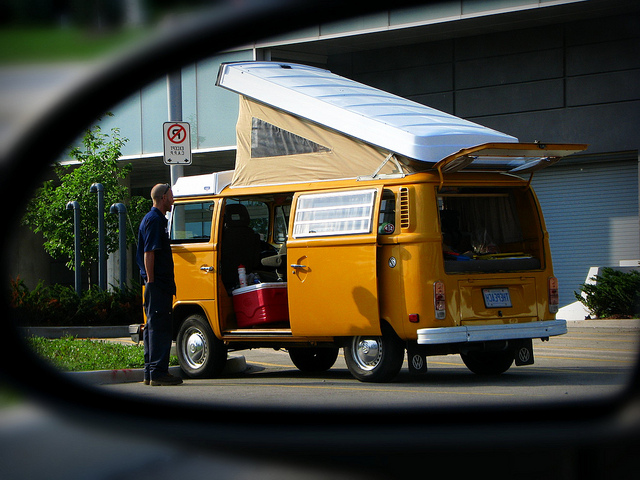

In [10]:
dataset[0]['image']

In [11]:
print(dataset[0]['caption'])

ภาพจากกระจกข้างรถยนต์ เห็นเป็นผู้ชายสวมเสื้อสีน้ำเงิน สวมกางเกงขายาวกำลังยืนอยู่ข้างรถตู้สีส้ม มีกระติกน้ำสีแดงตั้งอยู่ด้านในรถ


In [12]:
instruction = "จงบรรยายภาพนี้เป็นภาษาไทยแบบสั้น กระชับ และเป็นธรรมชาติ"
def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["caption"]} ]
        },
    ]
    return { "messages" : conversation }
pass

In [13]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

In [14]:
converted_dataset

[{'messages': [{'role': 'user',
    'content': [{'type': 'text',
      'text': 'จงบรรยายภาพนี้เป็นภาษาไทยแบบสั้น กระชับ และเป็นธรรมชาติ'},
     {'type': 'image',
      'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480>}]},
   {'role': 'assistant',
    'content': [{'type': 'text',
      'text': 'ภาพจากกระจกข้างรถยนต์ เห็นเป็นผู้ชายสวมเสื้อสีน้ำเงิน สวมกางเกงขายาวกำลังยืนอยู่ข้างรถตู้สีส้ม มีกระติกน้ำสีแดงตั้งอยู่ด้านในรถ'}]}]},
 {'messages': [{'role': 'user',
    'content': [{'type': 'text',
      'text': 'จงบรรยายภาพนี้เป็นภาษาไทยแบบสั้น กระชับ และเป็นธรรมชาติ'},
     {'type': 'image',
      'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480>}]},
   {'role': 'assistant',
    'content': [{'type': 'text',
      'text': 'รถบรรทุกสีฟ้า จอดหน้าเต็นท์สีแดงหลายหลัง โดยข้างหน้ามีเสาสีแดงบนเสาที่มีป้ายวงกลมสีดำและเขียนด้วยภาษาอังกฤษสีขาว'}]}]},
 {'messages': [{'role': 'user',
    'content': [{'type': 'text',
      'text': 'จงบรรยายภาพนี้เป็นภาษาไทยแบบส

In [17]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        #max_steps = 500,
        num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 1e-4,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 4,
        max_seq_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [18]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,000 | Num Epochs = 1 | Total steps = 1,250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 25,673,472 of 8,792,797,168 (0.29% trained)


Step,Training Loss
1,2.308568
2,2.090820
3,2.243842
4,2.230865
5,2.185569
6,1.968779
7,1.857709
8,1.712977
9,1.616614
10,1.661335


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1250/tokenizer_config.json.


process test set

In [19]:
from tqdm import tqdm
from PIL import Image

FastVisionModel.for_inference(model)

instruction = "คิดแคปชั่นรูปนี้ให้หน่อย"
test_cap = []

def generateCaption(image_path):
    image = Image.open(image_path).convert("RGB")
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": instruction}
        ]}
    ]
    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens = False,
        return_tensors = "pt",
    ).to("cuda")
    output = model.generate(**inputs, max_new_tokens = 100,
                      use_cache = True, temperature = 0.5, min_p = 0.1)
    caption = tokenizer.decode(output[0], skip_special_tokens=True).strip()
    test_cap.append(caption)

In [23]:
trainer.save_model("ipu10k-thai_caption_lora")
tokenizer.save_pretrained("ipu10k-thai_caption_lora")

Unsloth: Restored added_tokens_decoder metadata in ipu10k-thai_caption_lora/tokenizer_config.json.


['ipu10k-thai_caption_lora/processor_config.json']

In [24]:
from huggingface_hub import create_repo, upload_folder

repo_id = "KiruruP/Qwen3-VL-8B-ipu10k-thaicaption-lora"

create_repo(repo_id, exist_ok=True)

upload_folder(
    folder_path="ipu10k-thai_caption_lora",
    repo_id=repo_id,
    repo_type="model"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ption_lora/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...adapter_model.safetensors:   0%|          | 80.7kB /  103MB            

  ...on_lora/training_args.bin:   2%|2         |   135B / 5.71kB            

CommitInfo(commit_url='https://huggingface.co/KiruruP/Qwen3-VL-8B-ipu10k-thaicaption-lora/commit/5d7b828404c1f15f6bf6781dfbc1d7e77cb7ab1c', commit_message='Upload folder using huggingface_hub', commit_description='', oid='5d7b828404c1f15f6bf6781dfbc1d7e77cb7ab1c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/KiruruP/Qwen3-VL-8B-ipu10k-thaicaption-lora', endpoint='https://huggingface.co', repo_type='model', repo_id='KiruruP/Qwen3-VL-8B-ipu10k-thaicaption-lora'), pr_revision=None, pr_num=None)